In [ ]:
import pygimli as pg 
import matplotlib.pyplot as plt
import numpy as np
from pygimli.physics import ert
import pygimli.meshtools as mt
from scipy.interpolate import griddata
import pandas as pd
import os
output_dir="timelapse1_v2"
os.makedirs(output_dir, exist_ok=True)

31/03/26 - 20:25:55 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 


Data: Sensors: 21 data: 171, nonzero entries: ['a', 'b', 'k', 'm', 'n', 'valid']


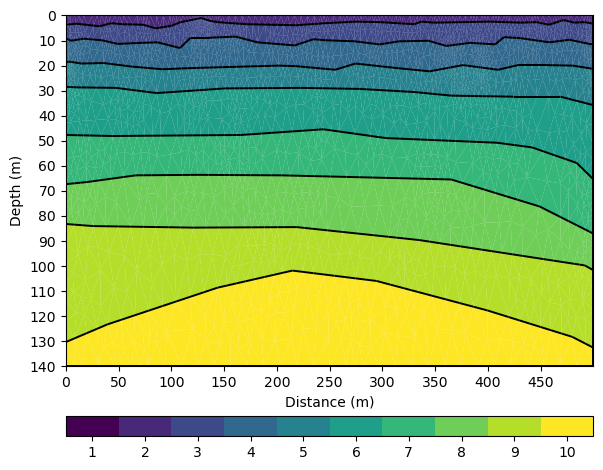

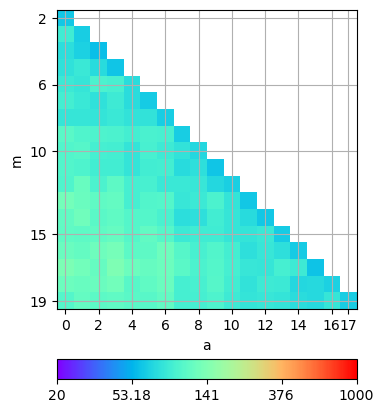

In [ ]:
world=mt.createWorld(start=[-1000,0],end=[1500,-1000],worldMarker=1)
poly=mt.createRectangle(start=[0, -140], end=[500, 0], marker=1)

interfaces = []

for i in range(9):
    coords = np.loadtxt(f'shape_{i}.txt')
    line = mt.createPolygon(coords, isClosed=False)
    interfaces.append(line)

geom = mt.mergePLC([world] + interfaces + [poly])

geom.addRegionMarker(pos=[0, -1], marker=2)
geom.addRegionMarker(pos=[0, -6], marker=3)
geom.addRegionMarker(pos=[0, -12], marker=4)
geom.addRegionMarker(pos=[0, -23], marker=5)
geom.addRegionMarker(pos=[0, -40], marker=6)
geom.addRegionMarker(pos=[0, -60], marker=7)
geom.addRegionMarker(pos=[0, -80], marker=8)
geom.addRegionMarker(pos=[0, -100], marker=9)
geom.addRegionMarker(pos=[0, -140], marker=10)


mesh_cut = mt.createMesh(geom, quality=34)

x_min,x_max= 0,500
y_min,y_max= -140,0

ax, cbar = pg.show(mesh_cut, data=mesh_cut.cellMarkers(), 
                   showMesh=False, aspect='auto', 
                   cmap=plt.get_cmap("viridis", 10))
cbar.mappable.set_clim(0.5, 10.5)
cbar.set_ticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

ax.set_xlim(0, 500)
ax.set_ylim(-140, 0)
ax.set_yticks(np.arange(-140, 1, 10)) 
ax.set_xticks(np.arange(0, 500, 50)) 
ax.set_xlabel("Distance (m)")   
ax.set_ylabel("Depth (m)")
ax.figure.savefig(os.path.join(output_dir, f'mesh_cut.png'))
#plt.draw()


spacing=25
scheme=ert.createData(
    elecs=np.linspace(start=0,stop=500,num=len(np.arange(0,501,spacing)))
    , schemeName='dd'
)
print(scheme)
for p in scheme.sensors():
    geom.createNode(p)
    geom.createNode(p-[0,0.1]) # create 2  nodes for FTDT
mesh_fwr=mt.createMesh(geom,quality=34)
rhomap=[[1,100],
        [2,100],
        [3,30],
        [4,200],
        [5,100],
        [6,50],
        [7,80],
        [8,150],
        [9,300],
        [10,400]
        ] # resistivity for each region
#pg.show(mesh_fwr,data=rhomap,label=pg.unit('res'), cMap='gist_rainbow',logScale=True,aspect='auto')

data=ert.simulate(mesh_fwr,scheme=scheme, res=rhomap, noiseLevel=0.05, noiseAbs=1e-6, seed=1337)

pg.info(np.linalg.norm(data['err']),np.linalg.norm(data['rhoa']))
pg.info('Simulated data: ',data)
pg.info('The data contains : ',data.dataMap().keys())
pg.info('Sim rhoa (min/max) : ' ,min(data['rhoa']), max(data['rhoa']))
pg.info('Selected data noise % (min/ma)x : ', min(data['err'])*100, max(data['err'])*100)

data.remove(data['rhoa']<0)
pg.info('filtered rhoa minmax dd : ', min(data['rhoa']), max(data['rhoa']))

os.makedirs(output_dir, exist_ok=True) #Make new dir to save files

data.save(os.path.join(output_dir, f'{output_dir}_dd.dat'))

#ert.show(data,cMap='rainbow',cMin=20,cMax=1000,logScale=True,title='DD')   #pseudosection
pg.viewer.mpl.showDataContainerAsMatrix(data,'a','m', 'rhoa',cMap='rainbow',cMin=20,cMax=1000,logScale=True,title='DD')

np.save(os.path.join(output_dir, f'{output_dir}_abmn_dd.npy'), np.column_stack([data['a'], data['b'], data['m'], data['n']]))
np.save(os.path.join(output_dir, f'{output_dir}_res_all_dd.npy'), np.column_stack([data['rhoa']]))
abmn_data_dd = np.load(os.path.join(output_dir, f'{output_dir}_abmn_dd.npy'))
res_data_dd=np.load(os.path.join(output_dir, f'{output_dir}_res_all_dd.npy')) 

In [ ]:
#timelapse, changing marker6 (layer 6), assume it changes due to pollution
new_vals=[70,50,40,30,20,10]

os.makedirs(f'{output_dir}/logs', exist_ok=True) #Make logs dir to save log files
os.makedirs(f'{output_dir}/timelapse', exist_ok=True) #Make timelapse dir to save data files
os.makedirs(f'{output_dir}/res_all_t', exist_ok=True) #Make res_all_t dir to save resistivity data files

for i, rho_val in enumerate(new_vals):
    rhomap[5][1]=rho_val
    data=ert.simulate(mesh_fwr,scheme=scheme, res=rhomap, noiseLevel=0.01, noiseAbs=1e-6, seed=1337)
    data.remove(data['rhoa']<0)


    filename=f'{output_dir}/timelapse/timelapse_{i}.dat'
    print(f'Value for marker 6: {new_vals[i]} Ohm.m, data saved to {filename}')
    with open(f'{output_dir}/logs/log_{i}.txt', 'w') as f:
        print(f"Step {i} | Marker6: {rho_val} ", file=f)
        print(f"Norm Err: {np.linalg.norm(data['err'])}", file=f)
        print(f"Min/Max Rhoa: {min(data['rhoa'])} / {max(data['rhoa'])}", file=f)
        print(f"Data: {data}", file=f)
    print(f'Log_{i}.txt created with details of Step {i}')
    data.save(filename)
    print(f'Done Step {i}')

    np.save(f'{output_dir}/res_all_t/res_all_t_{i}.npy', np.column_stack([data['rhoa']])) #Resistivity changes, keep inside the loop


np.save(f'{output_dir}/res_all_t/abmn.npy', np.column_stack([data['a'], data['b'], data['m'], data['n']])) #Geometry doesn't change.


Value for marker 6: 70 Ohm.m, data saved to timelapse1_v2/timelapse/timelapse_0.dat
Log_0.txt created with details of Step 0
Done Step 0
Value for marker 6: 50 Ohm.m, data saved to timelapse1_v2/timelapse/timelapse_1.dat
Log_1.txt created with details of Step 1
Done Step 1
Value for marker 6: 40 Ohm.m, data saved to timelapse1_v2/timelapse/timelapse_2.dat
Log_2.txt created with details of Step 2
Done Step 2
Value for marker 6: 30 Ohm.m, data saved to timelapse1_v2/timelapse/timelapse_3.dat
Log_3.txt created with details of Step 3
Done Step 3
Value for marker 6: 20 Ohm.m, data saved to timelapse1_v2/timelapse/timelapse_4.dat
Log_4.txt created with details of Step 4
Done Step 4
Value for marker 6: 10 Ohm.m, data saved to timelapse1_v2/timelapse/timelapse_5.dat
Log_5.txt created with details of Step 5
Done Step 5


In [ ]:
def fill_nan(image):
    image=image.copy()
    nan_mask = np.isnan(image)
    mean_value = np.nanmean(image)
    image[nan_mask] = mean_value
    return image, nan_mask

def compress(image, n_pixels, z_factor,rank): 
    image, nan_mask = fill_nan(image)
    U, S, Vt = np.linalg.svd(image, full_matrices=False)
    rank=len(S) if rank is None else rank
    U_reduced = U[:, :rank]
    S_reduced = S[:rank]
    Vt_reduced = Vt[:rank, :]
    compressed_image = np.dot(U_reduced, np.dot(np.diag(S_reduced), Vt_reduced))
    contributions = np.abs(U_reduced)  @ np.diag(S_reduced) @ np.abs(Vt_reduced)
    
    # Apply depth weighting to contributions
    rows, cols = np.arange(image.shape[0]), np.arange(image.shape[1])
    z = rows / np.max(rows)
    depth_weight = 1 + z_factor * z   
    depth_weight = depth_weight[:, None]
    contributions *= depth_weight

    contributions[nan_mask] = -np.inf

    #anchor points
    #first column (idx= 0)
    valid_rows_0 = np.flatnonzero(~nan_mask[:, 0])
    if valid_rows_0.size > 0:
        rows_min, rows_max, rows_mean = valid_rows_0[0], valid_rows_0[-1],valid_rows_0[valid_rows_0.size // 2]
        contributions[rows_min, 0],contributions[rows_max, 0], contributions[rows_mean, 0] = np.inf, np.inf, np.inf
    
    #set last column first row contribution to inf
    valid_cols= np.where(~nan_mask)[1]
    if valid_cols.size > 0:
        col_last = valid_cols.max()
        valid_rows_in_last_col = np.flatnonzero(~nan_mask[:, col_last])
        if valid_rows_in_last_col.size > 0:
            row_last = valid_rows_in_last_col[0]
            contributions[row_last, col_last] = np.inf

        unique_cols = np.unique(valid_cols)
        col_mean = unique_cols[unique_cols.size // 2]
        valid_rows_in_mean_col = np.flatnonzero(~nan_mask[:, col_mean])
        if valid_rows_in_mean_col.size > 0:
            contributions[valid_rows_in_mean_col[-1], col_mean] = np.inf

    flat_indices = np.argsort(contributions.flatten())[::-1][:n_pixels]
    significant_indices = np.unravel_index(flat_indices, image.shape)
    return compressed_image, significant_indices, nan_mask, contributions,rank
def reconstruct(image_shape, significant_indices, pixel_values):
    compressed_image = np.full(image_shape, np.nan)
    compressed_image[significant_indices] = pixel_values
    x, y = np.meshgrid(np.arange(image_shape[1]), np.arange(image_shape[0]))
    mask = ~np.isnan(compressed_image)
    x_known, y_known = x[mask], y[mask]
    values_known = compressed_image[mask]
    rbf_interpolator = Rbf(x_known, y_known, values_known, function='thin_plate')
    interpolated_image = rbf_interpolator(x, y)
    return interpolated_imagε

# def reconstruct(image_shape, significant_indices, pixel_values):
#     # Create an empty image with the given shape
#     compressed_image = np.full(image_shape, np.nan)
#     # Assign the provided pixel values to the significant indices
#     compressed_image[significant_indices] = pixel_values
#     # Interpolate to fill in the missing values
#     x, y = np.meshgrid(np.arange(image_shape[1]), np.arange(image_shape[0]))
#     mask = ~np.isnan(compressed_image)
#     interpolated_image = griddata(
#         (x[mask], y[mask]),  # Points with known values
#         compressed_image[mask],  # Known values
#         (x, y),  # Points to interpolate
#         method='linear'  # Interpolation 
#         )
    return interpolated_image

def plot_ert_checkerboard(data,plot=0):
    #Extract unique electrode positions
    electrodes = np.unique(data[['A', 'B', 'M', 'N']].values)
    electrode_map = {electrode: idx for idx, electrode in enumerate(sorted(electrodes))}
    #Create a grid
    grid_size = len(electrode_map)
    heatmap = np.full((grid_size, grid_size), np.nan)
    #Map values to the grid
    for _, row in data.iterrows():
        x = electrode_map[row['A']]
        y = electrode_map[row['M']]
        heatmap[y, x] = row['Res']
    if plot==1:
        #Plot the checkerboard heatmap
        plt.figure(figsize=(10, 8))
        plt.imshow(np.log10(heatmap), cmap='gist_rainbow', interpolation='nearest')
        plt.colorbar(label='ERT Measurement Value')
        plt.xticks(ticks=np.arange(grid_size), labels=sorted(electrode_map.keys()), rotation=90)
        plt.yticks(ticks=np.arange(grid_size), labels=sorted(electrode_map.keys()))
        plt.xlabel('Electrode A')
        plt.ylabel('Electrode N')
        plt.title('ERT Checkerboard Heatmap')
        plt.savefig(os.path.join(output_dir, f'{output_dir}_checkerboard_heatmap.png'))
        plt.close()
    return heatmap

In [ ]:
abmn=np.load(f'{output_dir}/res_all_t/abmn.npy')
#create the first dataframe for electrode mapping
res_all_0 = np.load(f'{output_dir}/res_all_t/res_all_t_0.npy')
data_all_0 = np.column_stack([abmn, res_all_0[:,0]])
data = pd.DataFrame(data_all_0, columns=['A','B','M','N','Res'])

electrodes = np.unique(data[['A', 'B', 'M', 'N']].values)
electrode_map = {electrode: idx for idx, electrode in enumerate(sorted(electrodes))}
image=plot_ert_checkerboard(data,plot=1) 

In [ ]:

import logging

pg_logger = logging.getLogger('pyGIMLi')
pg_logger.setLevel(logging.WARNING)

all_images = []          
all_significant_indices = [] 
all_reconstructed_images = []
all_best_z = []
all_n_pixels = []           
all_model_rmse = []             
all_inv1, all_inv2 = [], []
all_chi2_1, all_chi2_2 = [], []

# optimize for z_factor 
z_range = np.arange(0.0, 0.4, 0.05)

for i in range(len(new_vals)):
    res_all = np.load(f'{output_dir}/res_all_t/res_all_t_{i}.npy')
    data_all = np.column_stack([abmn, res_all[:, 0]])
    data = pd.DataFrame(data_all, columns=['A', 'B', 'M', 'N', 'Res'])
    image = plot_ert_checkerboard(data, plot=1) 

    # Original Data Inversion
    datafile = f'{output_dir}/timelapse/timelapse_{i}.dat'
    data_orig = pg.load(datafile)
    mgr1 = ert.ERTManager(data_orig)
    inv1 = mgr1.invert(lam=20, verbose=False, paraMaxCellSize=30, paraDepth=140)
    chi2_1 = mgr1.inv.chi2()
    inv1_array = np.asarray(inv1) 

    cell_depths=[]
    all_cels=mgr1.paraDomain.cells()

    for cell in all_cels:
        depth=cell.center()[1]
        cell_depths.append(depth)

    cell_depths=np.array(cell_depths)
    mask_depth=cell_depths<-5

    valid_mask = ~np.isnan(image)
    original_valid_pixels = image[valid_mask]
    n_pixels = original_valid_pixels.size

    #decreasing num of pixels
    for n in range(n_pixels, n_pixels//5, -n_pixels//10): 
        
        # initialize params 
        min_model_rmse = float('inf')
        best_z = None
        best_significant_indices = None
        best_nan_mask = None
        best_reconstructed_images = None
        best_inv2_array = None
        best_chi2_2 = None
        
        #find best z for n 
#decreasing num of pixels
    for n in range(n_pixels, n_pixels//5, -n_pixels//10): 
        
        # initialize params 
        min_model_rmse = float('inf')
        best_z = None
        best_significant_indices = None
        best_nan_mask = None
        best_reconstructed_images = None
        best_inv2_array = None
        best_chi2_2 = None
        
        # BYPASS για n = max pixels (Εξοικονόμηση χρόνου!)
        if n == n_pixels:
            best_z = 0.0
            min_model_rmse = 0.0
            best_inv2_array = inv1_array
            best_chi2_2 = chi2_1
            best_nan_mask = np.isnan(image)
            best_reconstructed_images = image.copy()
            best_significant_indices = np.where(~np.isnan(image))
            
        else:
            #find best z for n 
            for z_test in z_range:
                compressed_image, significant_indices, nan_mask, contributions, _ = compress(image.copy(), n, z_factor=z_test, rank=None)
                pixel_values = compressed_image[significant_indices]
                reconstructed_compressed_image = reconstruct(image.shape, significant_indices, pixel_values)       
                
                #map again 
                new_rhoa = []
                for _, row in data.iterrows():
                    x = electrode_map[row['A']]
                    y = electrode_map[row['M']]
                    new_rhoa.append(reconstructed_compressed_image[y, x])
                
                data_for_svd = pg.load(datafile)
                if len(data_for_svd['rhoa']) == len(new_rhoa):
                    data_for_svd['rhoa'] = np.array(new_rhoa)
                    rhoa_vals = np.array(data_for_svd['rhoa'])
                    mask_inv = np.isnan(rhoa_vals) | (rhoa_vals <= 0)
                    if np.any(mask_inv):
                        data_for_svd.remove(mask_inv)
                    
                mgr2 = ert.ERTManager(data_for_svd)
                inv2 = mgr2.invert(lam=20, verbose=False, paraMaxCellSize=30, paraDepth=140)
                chi2_2 = mgr2.inv.chi2()
                inv2_array = np.asarray(inv2)
                
                #RMSE FOR MODELS AFTER INVERSION...
                model_rmse = np.sqrt(np.mean((inv1_array[mask_depth] - inv2_array[mask_depth])**2))
                
                #KEEP THE PARAMS FOR THE BEST MODEL (lowest RMSE)
                if model_rmse < min_model_rmse:
                    min_model_rmse = model_rmse
                    best_z = z_test
                    best_significant_indices = significant_indices
                    best_nan_mask = nan_mask
                    best_reconstructed_images = reconstructed_compressed_image
                    best_inv2_array = inv2_array
                    best_chi2_2 = chi2_2
                
        print(f"Step {i}  N={int(n):03d}  Best z: {best_z:.2f}  Model RMSE: {min_model_rmse:.2f}  Chi2: {best_chi2_2:.2f}")

        current_image = image.copy()
        current_image[best_nan_mask] = np.nan 
        all_images.append(current_image)
        ####SAVE EVERYTHING TO DISK!!!
        #SAVE THE MESH 
        if i == 0 and n == n_pixels:
            mgr1.paraDomain.save(f'{output_dir}/paraDomain_mesh.bms')

        #SAVE ALL THE LISTS 
        all_n_pixels.append(n)
        all_model_rmse.append(min_model_rmse)
        all_best_z.append(best_z)
        all_chi2_1.append(chi2_1)
        all_chi2_2.append(best_chi2_2)
        all_inv1.append(inv1_array)
        all_inv2.append(best_inv2_array)
        all_significant_indices.append(best_significant_indices)
        all_reconstructed_images.append(best_reconstructed_images)
        
        #EVERYTHING TO DISK
        np.save(f'{output_dir}/all_n_pixels.npy', all_n_pixels)
        np.save(f'{output_dir}/model_rmse_list.npy', all_model_rmse)
        np.save(f'{output_dir}/best_z_list.npy', all_best_z)
        np.save(f'{output_dir}/chi2_1_list.npy', all_chi2_1)
        np.save(f'{output_dir}/chi2_2_list.npy', all_chi2_2)
        np.save(f'{output_dir}/inv1_list.npy', all_inv1) 
        np.save(f'{output_dir}/inv2_list.npy', all_inv2)
        
        np.save(f'{output_dir}/significant_indices_list.npy', np.array(all_significant_indices, dtype=object), allow_pickle=True)
        np.save(f'{output_dir}/reconstructed_images_list.npy', np.array(all_reconstructed_images, dtype=object), allow_pickle=True)

print("all steps done, all data, metrics (Model RMSE, Chi2) and inversion arrays safely saved.")

Step 0  N=171  Best z: 0.30  Model RMSE: 0.02  Chi2: 1.77
Step 0  N=153  Best z: 0.10  Model RMSE: 7.97  Chi2: 2.48
Step 0  N=135  Best z: 0.00  Model RMSE: 13.47  Chi2: 4.71
Step 0  N=117  Best z: 0.30  Model RMSE: 17.59  Chi2: 3.88
Step 0  N=099  Best z: 0.00  Model RMSE: 19.29  Chi2: 4.25
Step 0  N=081  Best z: 0.00  Model RMSE: 26.14  Chi2: 3.72
Step 0  N=063  Best z: 0.00  Model RMSE: 25.65  Chi2: 4.34
Step 0  N=045  Best z: 0.00  Model RMSE: 26.01  Chi2: 3.46
Step 1  N=171  Best z: 0.30  Model RMSE: 0.03  Chi2: 1.98
Step 1  N=153  Best z: 0.30  Model RMSE: 8.27  Chi2: 2.97
Step 1  N=135  Best z: 0.00  Model RMSE: 11.77  Chi2: 4.84
Step 1  N=117  Best z: 0.00  Model RMSE: 18.30  Chi2: 6.39
Step 1  N=099  Best z: 0.00  Model RMSE: 25.62  Chi2: 4.48
Step 1  N=081  Best z: 0.00  Model RMSE: 24.75  Chi2: 4.12
Step 1  N=063  Best z: 0.30  Model RMSE: 35.30  Chi2: 3.43
Step 1  N=045  Best z: 0.30  Model RMSE: 22.36  Chi2: 4.86
Step 2  N=171  Best z: 0.30  Model RMSE: 0.01  Chi2: 2.14
St

In [ ]:

comparisons_dir = os.path.join(output_dir, 'comparisons')
os.makedirs(comparisons_dir, exist_ok=True)

mesh = pg.load(f'{output_dir}/paraDomain_mesh.bms')
all_n_pixels = np.load(f'{output_dir}/all_n_pixels.npy')
all_inv1 = np.load(f'{output_dir}/inv1_list.npy', allow_pickle=True)
all_inv2 = np.load(f'{output_dir}/inv2_list.npy', allow_pickle=True)
n_steps=len(new_vals)
steps_per_i = len(all_n_pixels) // n_steps

all_n_pixels = all_n_pixels.reshape(n_steps, steps_per_i)
all_inv1 = np.stack(all_inv1).reshape(n_steps, steps_per_i, -1)
all_inv2 = np.stack(all_inv2).reshape(n_steps, steps_per_i, -1)
plot_cell_depths = []
for cell in mesh.cells():
    plot_cell_depths.append(cell.center()[1])
mask_depth = np.array(plot_cell_depths) <-5

for i in range(len(new_vals)):
    for j in range(steps_per_i):
        inv1 = all_inv1[i, j]
        inv2 = all_inv2[i, j]
        n_pixels = all_n_pixels[i, j]

        fig, axes = plt.subplots(1, 3, figsize=(16, 6))
        
        #inv1
        pg.show(mesh, data=inv1, ax=axes[0], cMap='rainbow', cMin=20, cMax=300, logScale=True)
        axes[0].set_title(f'Step {i} | N={int(n_pixels)} | Original Data Inversion')
        
        #inv2(compressed)
        pg.show(mesh, data=inv2, ax=axes[1], cMap='rainbow', cMin=20, cMax=300, logScale=True)
        axes[1].set_title(f'Step {i} | N={int(n_pixels)} | SVD Compressed Data Inversion')
        
        #difference Plot (Ratio)
        difference=(inv2/inv1)
        pg.show(mesh, data=difference, ax=axes[2], cMap='bwr', cMin=0.5, cMax=1.5, logScale=False)
        axes[2].set_title(f'Step {i}  N={int(n_pixels)}  Difference (SVD/Original)')
        
        #disp rmse on the difference plot
        rmse = np.sqrt(np.mean((inv1[mask_depth] - inv2[mask_depth])**2))
        axes[2].text(0.05, 0.95, f'RMSE(depth<-5): {rmse:.2f}',
                     transform=axes[2].transAxes,
                       verticalalignment='top', horizontalalignment='left',
                         fontsize=8, bbox=dict(facecolor='white', alpha=0.8))

        for ax in axes:
            ax.set_ylim(-140, 0)
            ax.set_xlim(0, 500)

        plt.tight_layout()
        plt.savefig(os.path.join(comparisons_dir, f'rbf_deep_comparison_step_{i}_n_{int(n_pixels):03d}.png'))
        plt.close(fig)

print("done plotting")

done plotting


: 